State Reduces - These are the functions which are used to update the state in the graph 

Simple state reduces


In [4]:
from operator import add
from langgraph.graph import StateGraph  , START , END
from typing import TypedDict ,Annotated


In [5]:
#Create a state 
class State:
    #Sum state 
    sum :  Annotated[list[int] , add]  # It will have a type of list where the elenments are int and after that it must preform the operation add 


Create node of the agent    

In [3]:
def node1(state :State):
    return {
        "sum" : [state["sum"][0] + 1 ]
    }

Create a simple agent

In [6]:
builder = StateGraph(State)

builder.add_node("node1" , node1)

builder.add_edge(START , "node1")

builder.add_edge("node1" , END)


graph = builder.compile()

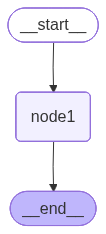

In [7]:
graph

In [9]:
graph.invoke({
    'sum' : [1]
})

{'sum': [1, 2]}

Create a agent with more nodes having the same state update 

In [11]:
def node1(state :State):
    return {
        "sum" : [state["sum"][-1] + 1 ]
    }
def node2(state:State):
    print("Node 2 ----")
    return {
        "sum" :[state["sum"][-1] + 1 ]
    }
def node3(state:State):
    print("Node 3 ----")
    return {
        "sum" :[state["sum"][-1] + 1 ]
    }


In [12]:
builder = StateGraph(State)

builder.add_node("node1" , node1)
builder.add_node("node2" , node2)
builder.add_node("node3" , node3)

builder.add_edge("node1" , "node2")
builder.add_edge("node1" , "node3")
builder.add_edge(START , "node1")

builder.add_edge("node2" , END)
builder.add_edge("node3" , END)

graph = builder.compile()

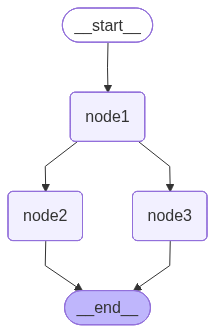

In [13]:
graph

In [15]:
graph.invoke({
    "sum" : [1]
})

Node 2 ----Node 3 ----



{'sum': [1, 2, 3, 3]}

This type of query be handled by the current pre build reduces 

In [17]:
try:

    graph.invoke({
        "sum" : None
    })
except Exception as e:
    print(e)

can only concatenate list (not "NoneType") to list


Add a custom reducer function for the state 


In [18]:
def custome_reducer(left_list : list[int] | None  ,right_list : list[int] | None  )-> list:
    """Function is a custom reduces which takes a list and addes the values 
    
    
    Keyword arguments:
    left_list -- prevoirs value of the state 
    right_list --Current updated lsit 
    Return: list with summed output 
    """

    if not left_list:
        left_list = []
    if not right_list:
        right_list =[]
    return left_list + right_list
    

In [22]:
class CustomeState(TypedDict):
    sum: Annotated[list[int] , custome_reducer]

In [33]:
def node1(state: CustomeState):

    current_val = state["sum"][-1] if state["sum"] else 0
    return {"sum": [current_val + 1]}

def node2(state: CustomeState):
    print("Node 2 ----")
    current_val = state["sum"][-1] if state["sum"] else 0
    return {"sum": [current_val + 1]}

def node3(state: CustomeState):
    print("Node 3 ----")
    current_val = state["sum"][-1] if state["sum"] else 0
    return {"sum": [current_val + 1]}

In [34]:
builder1 = StateGraph(CustomeState)

builder1.add_node("node1", node1)
builder1.add_node("node2", node2)
builder1.add_node("node3", node3)

builder1.add_edge(START, "node1")
builder1.add_edge("node1", "node2")
builder1.add_edge("node1", "node3")
builder1.add_edge("node2", END)
builder1.add_edge("node3", END)

graph1 = builder1.compile()

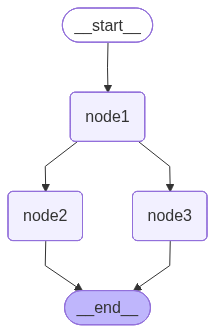

In [35]:
graph1

In [36]:
graph1.invoke({
    "sum" : None
})

Node 2 ----Node 3 ----



{'sum': [1, 2, 2]}